# 03 – RT-DETR: Entrenamiento en Google Colab

**Proyecto:** Detección Automática de Fracturas Óseas en Radiografías  
**Materia:** Visión por Computadora II – CEIA/FIUBA  
**Autores:** Lucia T. Capon Paul · César Andrés Orellana · Leandro Britez

---

Este notebook está pensado para correr en **Google Colab con GPU**. Antes de ejecutar cualquier celda:

1. Ir a **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4 o A100)**.
2. Tener en Google Drive la carpeta `VPCII_TP/` con:
   - `dataset_preprocessed.zip` (el dataset con CLAHE + unsharp masking)

## Estructura

| Sección | Qué hace |
|---|---|
| 0 | Verificar GPU y montar Drive |
| 1 | Instalar dependencias |
| 2 | Preparar el dataset |
| 3 | Configuración del experimento |
| 3.5 | Limpieza de checkpoints (opcional) |
| 4 | Cargar el modelo |
| 5 | Entrenar |
| 6 | Curvas de entrenamiento |
| 7 | Evaluación en validación |
| 8 | Evaluación en test |
| 9 | Métricas por clase |
| 10 | Benchmark de latencia |
| 11 | Matriz de confusión |
| 12 | Visualización de predicciones |
| 13 | Guardar resultados en Drive |

---
## Sección 0 – Verificar GPU y montar Drive

Lo primero que hacemos es verificar que Colab nos asignó una GPU. Sin GPU el entrenamiento tardaría horas para algo que con GPU tarda minutos. Después montamos Google Drive para acceder al dataset y para guardar los resultados (si no guardamos en Drive, todo se pierde cuando se desconecta la sesión).

In [1]:
import torch

# Verificar GPU
print(f'CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('SIN GPU — ir a Entorno de ejecución → Cambiar tipo de entorno → GPU')

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado en /content/drive')

CUDA disponible : True
GPU             : NVIDIA A100-SXM4-80GB
VRAM            : 85.1 GB
Mounted at /content/drive
Drive montado en /content/drive


---
## Sección 1 – Instalar dependencias

Colab ya tiene PyTorch instalado con soporte CUDA, así que solo necesitamos instalar `ultralytics` (que incluye RT-DETR) y algunas librerías auxiliares. La instalación tarda ~1 minuto.

In [2]:
!pip install -q ultralytics opencv-python-headless seaborn

# Verificar versiones después de instalar
import ultralytics
print(f'ultralytics : {ultralytics.__version__}')
print(f'torch       : {torch.__version__}')

import numpy as np
print(f'numpy       : {np.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics : 8.4.120
torch       : 2.11.0+cu128
numpy       : 2.0.2


---
## Sección 2 – Preparar el dataset

Descomprimimos el dataset desde Drive hacia `/content/`. Esto hay que hacerlo cada vez que arranca una nueva sesión de Colab porque `/content/` se borra al desconectarse. Drive no se borra, entonces el ZIP siempre está disponible.

El `if not os.path.exists(...)` evita descomprimir de nuevo si ya lo hicimos antes en la misma sesión (por ejemplo, si reconectamos sin reiniciar).

In [3]:
import os

# ── Rutas en Drive ────────────────────────────────────────────────────────────
DRIVE_ROOT   = '/content/drive/MyDrive/VPCII_TP'
ZIP_PATH     = f'{DRIVE_ROOT}/dataset_preprocessed.zip'
RESULTS_DRIVE = f'{DRIVE_ROOT}/resultados_rtdetr'

# ── Rutas en Colab (locales, rápidas para I/O de entrenamiento) ───────────────
DATASET_DIR  = '/content/dataset'
DATA_YAML    = f'{DATASET_DIR}/bone-fracture-detection-daoon-1-preprocessed/data.yaml'
RESULTS_LOCAL = '/content/rtdetr_results'

# Verificar que el ZIP existe en Drive
assert os.path.exists(ZIP_PATH), (
    f'No se encontró el ZIP en {ZIP_PATH}\n'
    'Verificar que dataset_preprocessed.zip esté en MyDrive/VPCII_TP/'
)

# Descomprimir solo si no existe ya
if not os.path.exists(DATA_YAML):
    print('Descomprimiendo dataset...')
    os.makedirs(DATASET_DIR, exist_ok=True)
    !unzip -q "{ZIP_PATH}" -d "{DATASET_DIR}"
    print('Listo.')
else:
    print('Dataset ya descomprimido, saltando.')

# Crear carpeta de resultados en Drive
os.makedirs(RESULTS_DRIVE, exist_ok=True)
os.makedirs(RESULTS_LOCAL, exist_ok=True)

print(f'data.yaml       : {DATA_YAML}')
print(f'Resultados local: {RESULTS_LOCAL}')
print(f'Resultados Drive: {RESULTS_DRIVE}')

Descomprimiendo dataset...
Listo.
data.yaml       : /content/dataset/bone-fracture-detection-daoon-1-preprocessed/data.yaml
Resultados local: /content/rtdetr_results
Resultados Drive: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr


In [4]:
# Verificar que el dataset está completo
import yaml
import pandas as pd
from pathlib import Path

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names']
NUM_CLASSES = data_cfg['nc']
DATA_ROOT = Path(DATA_YAML).parent

rows = []
for split in ('train', 'valid', 'test'):
    imgs   = list((DATA_ROOT / split / 'images').glob('*.jpg'))
    labels = list((DATA_ROOT / split / 'labels').glob('*.txt'))
    rows.append({'Split': split, 'Imágenes': len(imgs), 'Labels': len(labels)})

print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')
print(pd.DataFrame(rows).set_index('Split').to_string())

Clases (6): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive']
       Imágenes  Labels
Split                  
train      3631    3631
valid       348     348
test        169     169


---
## Sección 3 – Configuración del experimento

En el proyecto local teníamos los hiperparámetros en `configs/model2.yaml`. Acá los definimos directamente en el notebook para que sea autocontenido. Los valores son exactamente los mismos del YAML.

In [ ]:
import random

SEED     = 42
RUN_NAME = 'rtdetr_fracture'
DEVICE   = 0  # GPU en Colab

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Hiperparámetros 
CFG = {
    'model_weights'  : 'rtdetr-l.pt',
    'epochs'         : 100,
    'patience'       : 20,  # corta si no mejora el fitness en 20 épocas seguidas
    'imgsz'          : 640,
    'batch'          : 8,
    'optimizer'      : 'AdamW',  
    'lr0'            : 0.0001,
    'lrf'            : 0.00001,
    'weight_decay'   : 0.0001,
    'warmup_epochs'  : 2.0,
    'hsv_h'          : 0.015,
    'hsv_s'          : 0.7,
    'hsv_v'          : 0.4,
    'degrees'        : 0.0,
    'translate'      : 0.1,
    'scale'          : 0.5,
    'flipud'         : 0.0,
    'fliplr'         : 0.5,
    'mosaic'         : 0.0,  
    'mixup'          : 0.0,   
    'conf'           : 0.25,
    'iou'            : 0.7,
}

print('Configuración del experimento:')
for k, v in CFG.items():
    print(f'  {k:<18}: {v}')

Configuración del experimento:
  model_weights     : rtdetr-l.pt
  epochs            : 100
  patience          : 20
  imgsz             : 640
  batch             : 8
  optimizer         : AdamW
  lr0               : 0.0001
  lrf               : 1e-05
  weight_decay      : 0.0001
  warmup_epochs     : 2.0
  hsv_h             : 0.015
  hsv_s             : 0.7
  hsv_v             : 0.4
  degrees           : 0.0
  translate         : 0.1
  scale             : 0.5
  flipud            : 0.0
  fliplr            : 0.5
  mosaic            : 0.0
  mixup             : 0.0
  conf              : 0.25
  iou               : 0.7


---
## Sección 3.5 – Limpieza de checkpoints (opcional)

Si el entrenamiento anterior divergió (NaN en `cls_loss`, típico de AMP en RT-DETR) y ya guardó checkpoints en Drive, hay que borrarlos antes de reentrenar. No alcanza con borrar `checkpoints/last.pt` y `checkpoints/best.pt`: si ese entrenamiento llegó a completar sus épocas, la Sección 13 también copió el run entero a `resultados_rtdetr/rtdetr_fracture/`, y la Sección 4 usa `resultados_rtdetr/rtdetr_fracture/weights/best.pt` como primera señal de "entrenamiento ya terminado" — si ese archivo existe, el notebook saltearía el reentrenamiento y cargaría el checkpoint corrupto.

Poné `CLEAN_CHECKPOINTS = True` una sola vez para forzar un entrenamiento desde cero. Volvé a dejarlo en `False` después de correr esta celda (para no borrar accidentalmente un checkpoint válido si reconectás la sesión).

In [ ]:
CLEAN_CHECKPOINTS = True  # ← poner en True una vez para limpiar checkpoints corruptos, después volver a False

if CLEAN_CHECKPOINTS:
    import shutil

    # 1. Checkpoints incrementales (por época)
    checkpoints_dir = Path(RESULTS_DRIVE) / 'checkpoints'
    for fname in ('last.pt', 'best.pt', 'args.yaml'):
        p = checkpoints_dir / fname
        if p.exists():
            p.unlink()
            print(f'Eliminado: {p}')

    # 2. Run completo 
    run_dir_drive = Path(RESULTS_DRIVE) / RUN_NAME
    if run_dir_drive.exists():
        shutil.rmtree(run_dir_drive)
        print(f'Eliminado: {run_dir_drive}')

    # 3. Run local 
    run_dir_local = Path(RESULTS_LOCAL) / RUN_NAME
    if run_dir_local.exists():
        shutil.rmtree(run_dir_local)
        print(f'Eliminado: {run_dir_local}')

    print('\nLimpieza completa. Recordá volver a poner CLEAN_CHECKPOINTS = False.')
else:
    print('CLEAN_CHECKPOINTS = False → sin limpieza, se respeta el checkpoint existente si lo hay.')

Eliminado: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/checkpoints/last.pt
Eliminado: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/checkpoints/best.pt
Eliminado: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/checkpoints/args.yaml

Limpieza completa. Recordá volver a poner CLEAN_CHECKPOINTS = False.


---
## Sección 4 – Cargar el modelo preentrenado

Ultralytics descarga automáticamente `rtdetr-l.pt` (~130 MB) desde sus servidores. Tarda ~30 segundos la primera vez. Si la sesión se reinicia, vuelve a descargarlo (no se guarda en Drive a menos que lo especifiquemos, pero es rápido).

In [7]:
from ultralytics import RTDETR
import shutil, torch

CHECKPOINT_DRIVE = Path(RESULTS_DRIVE) / 'checkpoints'
CHECKPOINT_DRIVE.mkdir(parents=True, exist_ok=True)

RUN_DRIVE      = Path(RESULTS_DRIVE) / RUN_NAME
BEST_PT_DRIVE  = RUN_DRIVE / 'weights' / 'best.pt'
LAST_PT_DRIVE  = CHECKPOINT_DRIVE / 'last.pt'
ARGS_DRIVE     = CHECKPOINT_DRIVE / 'args.yaml'
LAST_PT_LOCAL  = Path(RESULTS_LOCAL) / RUN_NAME / 'weights' / 'last.pt'
ARGS_LOCAL     = Path(RESULTS_LOCAL) / RUN_NAME / 'args.yaml'

def _epoch_in_checkpoint(pt_path):
    ckpt = torch.load(pt_path, map_location='cpu', weights_only=False)
    return int(ckpt.get('epoch', -1))

# ── Detectar estado ───────────────────────────────────────────────────────
if BEST_PT_DRIVE.exists():
    TRAINING_STATE = 'done'
elif LAST_PT_DRIVE.exists():
    saved_epoch = _epoch_in_checkpoint(LAST_PT_DRIVE)
    if saved_epoch + 1 >= CFG['epochs']:
        TRAINING_STATE = 'done'
    else:
        TRAINING_STATE = 'resume'
        print(f'Checkpoint en época {saved_epoch + 1}/{CFG["epochs"]} → reanudando')
else:
    TRAINING_STATE = 'fresh'

# ── Cargar modelo según estado ────────────────────────────────────────────
if TRAINING_STATE == 'done':
    if BEST_PT_DRIVE.exists():
        dest_run = Path(RESULTS_LOCAL) / RUN_NAME
        if not dest_run.exists():
            shutil.copytree(str(RUN_DRIVE), str(dest_run))
        BEST_WEIGHTS = dest_run / 'weights' / 'best.pt'
    else:
        BEST_WEIGHTS = Path(RESULTS_LOCAL) / RUN_NAME / 'weights' / 'best.pt'
        BEST_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(CHECKPOINT_DRIVE / 'best.pt', BEST_WEIGHTS)
    RUN_DIR    = BEST_WEIGHTS.parent.parent
    model_best = RTDETR(str(BEST_WEIGHTS))
    print(f'Entrenamiento ya completo ({CFG["epochs"]} épocas).')
    print(f'best.pt cargado desde : {BEST_WEIGHTS}')

elif TRAINING_STATE == 'resume':
    # Restaurar last.pt Y args.yaml — Ultralytics necesita ambos
    LAST_PT_LOCAL.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(LAST_PT_DRIVE, LAST_PT_LOCAL)
    if ARGS_DRIVE.exists():
        shutil.copy(ARGS_DRIVE, ARGS_LOCAL)
    model = RTDETR(str(LAST_PT_LOCAL))
    print(f'Checkpoint restaurado en: {LAST_PT_LOCAL}')

else:
    model = RTDETR(CFG['model_weights'])
    print(f'Entrenamiento nuevo desde: {CFG["model_weights"]}')

print(f'Estado detectado : {TRAINING_STATE}')
print(f'Clases objetivo  : {NUM_CLASSES} ({CLASS_NAMES})')
if TRAINING_STATE != 'done':
    model.info(verbose=False)


Entrenamiento nuevo desde: rtdetr-l.pt
Estado detectado : fresh
Clases objetivo  : 6 (['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive'])


---
## Sección 5 – Entrenamiento

Entrenamos con los hiperparámetros definidos arriba. Los resultados se guardan localmente en `/content/rtdetr_results/` durante el entrenamiento (I/O más rápido que escribir directo a Drive).



In [8]:
if TRAINING_STATE == 'done':
    print('Entrenamiento ya completo — sección 5 saltada.')
    print('Podés ir directo a las secciones 6 a 13.')
else:
    def backup_to_drive(trainer):
        """Copia last.pt, best.pt y args.yaml a Drive al final de cada época."""
        for fname in ('best.pt', 'last.pt'):
            src = Path(trainer.save_dir) / 'weights' / fname
            if src.exists():
                shutil.copy(src, CHECKPOINT_DRIVE / fname)
        src_args = Path(trainer.save_dir) / 'args.yaml'
        if src_args.exists():
            shutil.copy(src_args, CHECKPOINT_DRIVE / 'args.yaml')

    model.add_callback('on_train_epoch_end', backup_to_drive)
    print(f'Backup automático activado → {CHECKPOINT_DRIVE}')

    if TRAINING_STATE == 'resume':
        # Ruta explícita: Ultralytics no busca el run más reciente sino el checkpoint
        # específico, y lee args.yaml desde la misma carpeta
        train_results = model.train(resume=str(LAST_PT_LOCAL))
    else:
        train_results = model.train(
            data=DATA_YAML,
            epochs=CFG['epochs'],
            patience=CFG['patience'],  # early stopping si no mejora
            imgsz=CFG['imgsz'],
            batch=CFG['batch'],
            optimizer=CFG['optimizer'],  # explícito: evita que optimizer=auto ignore lr0/momentum
            lr0=CFG['lr0'],
            lrf=CFG['lrf'],
            weight_decay=CFG['weight_decay'],
            warmup_epochs=CFG['warmup_epochs'],
            hsv_h=CFG['hsv_h'],
            hsv_s=CFG['hsv_s'],
            hsv_v=CFG['hsv_v'],
            degrees=CFG['degrees'],
            translate=CFG['translate'],
            scale=CFG['scale'],
            flipud=CFG['flipud'],
            fliplr=CFG['fliplr'],
            mosaic=CFG['mosaic'],
            mixup=CFG['mixup'],
            project=RESULTS_LOCAL,
            name=RUN_NAME,
            exist_ok=True,
            seed=SEED,
            device=DEVICE,
            amp=False,      # desactiva fp16 — previene NaN en attention layers de RT-DETR
            verbose=True,
        )

    RUN_DIR      = Path(train_results.save_dir)
    BEST_WEIGHTS = RUN_DIR / 'weights' / 'best.pt'
    model_best   = RTDETR(str(BEST_WEIGHTS))

    print(f'Entrenamiento finalizado.')
    print(f'Mejor checkpoint local : {BEST_WEIGHTS}')
    print(f'Mejor checkpoint Drive : {CHECKPOINT_DRIVE}/best.pt')


Backup automático activado → /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/checkpoints
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/bone-fracture-detection-daoon-1-preprocessed/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=1e-05, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      9.88G      1.462      1.041      1.017          4        640: 100% ━━━━━━━━━━━━ 454/454 3.4it/s 2:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.3it/s 3.5s
                   all        348        204    1.5e-05     0.0312   1.31e-05    1.6e-06

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      11.6G      1.339     0.6861     0.7713          7        640: 0% ──────────── 0/454  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      11.6G      1.112      1.085     0.6599          6        640: 100% ━━━━━━━━━━━━ 454/454 3.6it/s 2:08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 9.0it/s 2.4s
                   all        348        204    0.00115       0.26   0.000692   0.000141

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      11.6G      1.199     0.7319     0.6797          7        640: 0% ──────────── 0/454  0.3s

...

     56/100      11.6G     0.4257     0.4668     0.1958          5        640: 100% ━━━━━━━━━━━━ 454/454 3.5it/s 2:08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 8.8it/s 2.5s
                   all        348        204      0.376      0.295      0.229     0.0796

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     57/100      11.6G     0.3081     0.4171     0.1427          4        640: 0% ──────────── 0/454  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     57/100      11.6G     0.4194      0.471     0.1894          4        640: 100% ━━━━━━━━━━━━ 454/454 3.5it/s 2:08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 8.8it/s 2.5s
                   all        348        204      0.314      0.284      0.224      0.078

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     58/100      11.6G     0.4184     0.4716     0.1907          6        640: 0% ──────────── 0/454  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     58/100      11.6G     0.4101     0.4647     0.1894          8        640: 100% ━━━━━━━━━━━━ 454/454 3.5it/s 2:08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 8.9it/s 2.5s
                   all        348        204      0.356      0.277      0.242     0.0835
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 38, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

58 epochs completed in 2.159 hours.
Optimizer stripped from /content/rtdetr_results/rtdetr_fracture/weights/last.pt, 66.2MB
Optimizer stripped from /content/rtdetr_results/rtdetr_fracture/weights/best.pt, 66.2MB

Validating /content/rtdetr_results/rtdetr_fracture/weights/best.pt...
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr

---
## Sección 6 – Curvas de entrenamiento

Graficamos loss y métricas de validación por época para ver si el entrenamiento convergió bien.

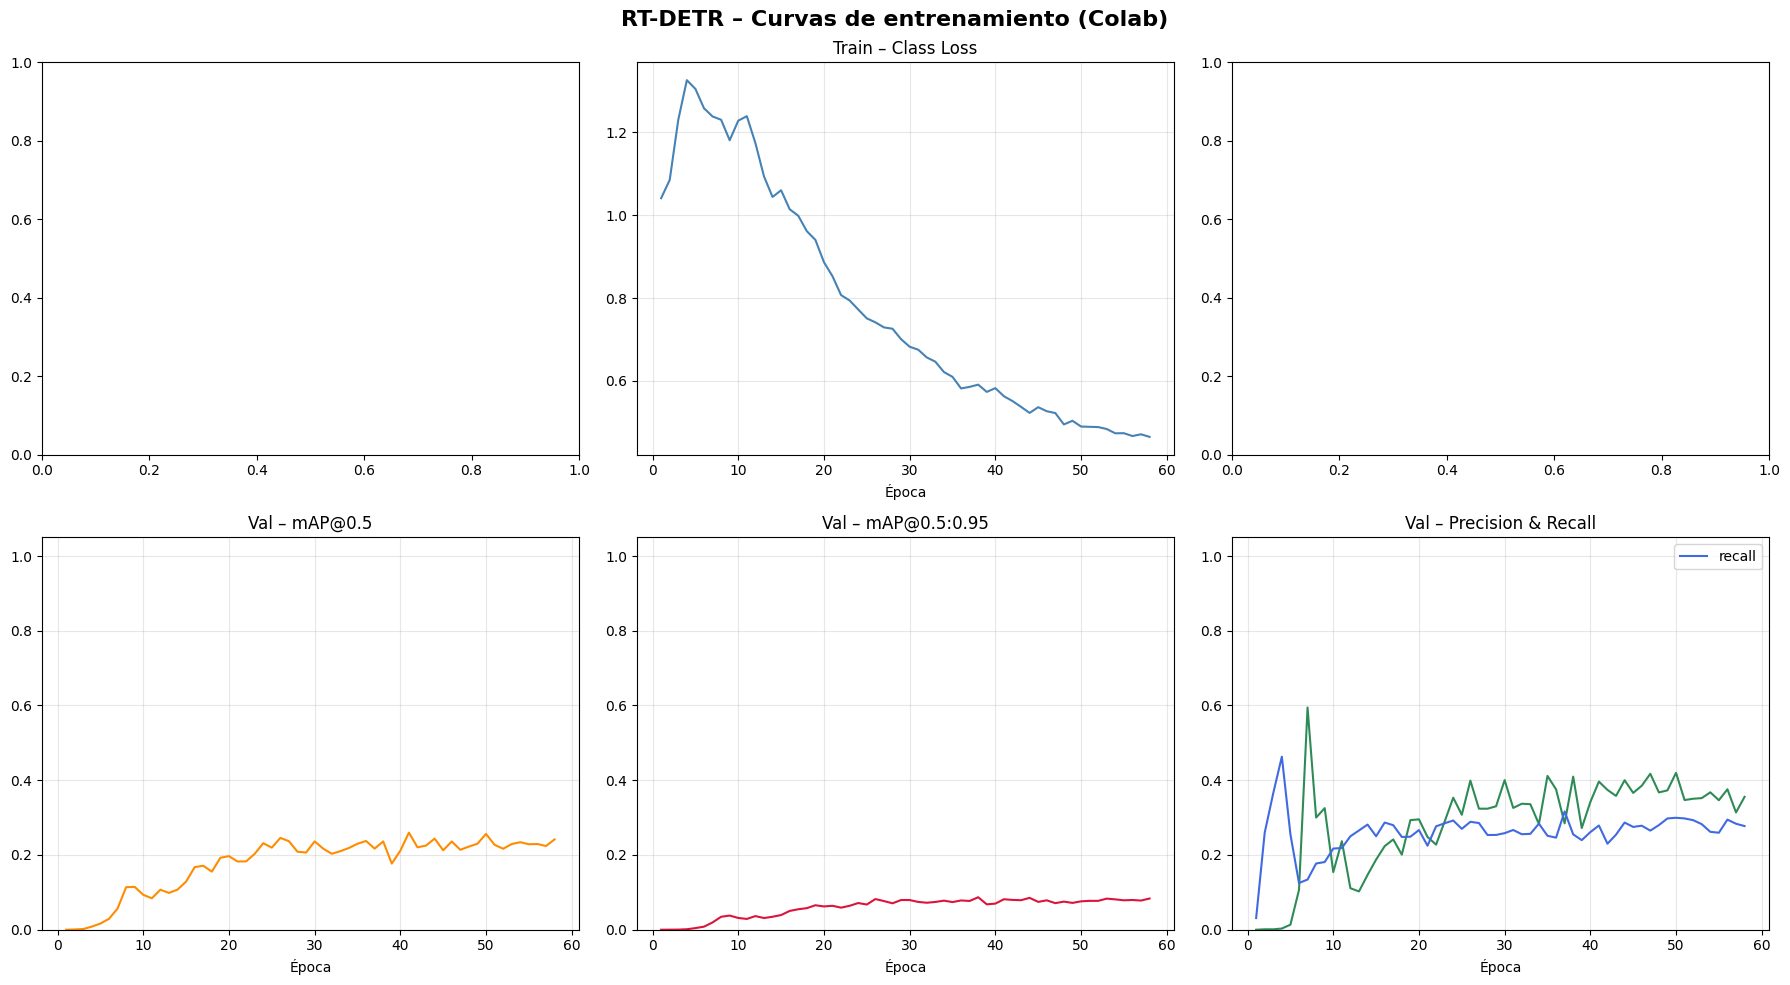

In [9]:
import matplotlib.pyplot as plt

results_csv = RUN_DIR / 'results.csv'
df_results  = pd.read_csv(results_csv)
df_results.columns = df_results.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('RT-DETR – Curvas de entrenamiento (Colab)', fontsize=16, fontweight='bold')

ep = df_results['epoch']

for ax, col, title, color in [
    (axes[0,0], 'train/box_loss',         'Train – Box Loss',         'steelblue'),
    (axes[0,1], 'train/cls_loss',         'Train – Class Loss',       'steelblue'),
    (axes[0,2], 'train/dfl_loss',         'Train – DFL Loss',         'steelblue'),
    (axes[1,0], 'metrics/mAP50(B)',       'Val – mAP@0.5',            'darkorange'),
    (axes[1,1], 'metrics/mAP50-95(B)',    'Val – mAP@0.5:0.95',       'crimson'),
    (axes[1,2], 'metrics/precision(B)',   'Val – Precision & Recall', 'seagreen'),
]:
    if col in df_results.columns:
        ax.plot(ep, df_results[col], color=color, linewidth=1.5)
        if col == 'metrics/precision(B)' and 'metrics/recall(B)' in df_results.columns:
            ax.plot(ep, df_results['metrics/recall(B)'], color='royalblue',
                    linewidth=1.5, label='recall')
            ax.legend()
        ax.set_title(title); ax.set_xlabel('Época'); ax.grid(alpha=0.3)
        if 'metrics' in col:
            ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(RUN_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 7 – Evaluación en validación

Cargamos `best.pt` y evaluamos sobre el split de validación para verificar que el checkpoint es correcto.

In [ ]:
val_results = model_best.val(
    data=DATA_YAML, split='val',
    imgsz=CFG['imgsz'], batch=CFG['batch'],
    iou=CFG['iou'], 
    device=DEVICE, verbose=True,
)

print('\n' + '='*50)
print('  RT-DETR – Validación')
print('='*50)
print(f'  mAP@0.5      : {val_results.box.map50:.4f}')
print(f'  mAP@0.5:0.95 : {val_results.box.map:.4f}')
print(f'  Precision    : {val_results.box.mp:.4f}')
print(f'  Recall       : {val_results.box.mr:.4f}')




Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 315 layers, 31,996,070 parameters, 0 gradients, 105.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1662.4±464.3 MB/s, size: 34.6 KB)
val: Scanning /content/dataset/bone-fracture-detection-daoon-1-preprocessed/valid/labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348 104.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 12.6it/s 3.5s
                   all        348        204       0.41      0.255      0.237     0.0865
        elbow positive         28         29      0.208      0.103      0.037      0.013
      fingers positive         41         48      0.232     0.0417       0.13     0.0383
      forearm fracture         37         43      0.626      0.372      0.393      0.176
      humerus fracture         31         36       0.62      0.528      0.5

---
## Sección 8 – Evaluación en test (métricas finales)

Esta es la evaluación definitiva. El test se usa **una sola vez** y sus números son los que van al paper.

In [ ]:
test_results = model_best.val(
    data=DATA_YAML, split='test',
    imgsz=CFG['imgsz'], batch=CFG['batch'],
    iou=CFG['iou'], 
    device=DEVICE, verbose=True, save_json=True,
)

P  = test_results.box.mp
R  = test_results.box.mr
F1 = 2 * P * R / (P + R + 1e-9)

print('\n' + '='*50)
print('  RT-DETR – TEST (resultados finales)')
print('='*50)
print(f'  mAP@0.5      : {test_results.box.map50:.4f}')
print(f'  mAP@0.5:0.95 : {test_results.box.map:.4f}')
print(f'  Precision    : {P:.4f}')
print(f'  Recall       : {R:.4f}')
print(f'  F1-Score     : {F1:.4f}')

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 315 layers, 31,996,070 parameters, 0 gradients, 105.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1409.2±463.2 MB/s, size: 32.0 KB)
val: Scanning /content/dataset/bone-fracture-detection-daoon-1-preprocessed/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 64.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 7.9it/s 2.8s
                   all        169         96       0.32      0.257      0.247     0.0802
        elbow positive         13         17          0          0      0.043    0.00828
      fingers positive         22         27      0.395      0.122       0.14     0.0266
      forearm fracture         13         14       0.72      0.553      0.512      0.167
      humerus fracture         14         15      0.387      0.467      0.375  

---
## Sección 9 – Métricas por clase

El mAP global promedia todas las clases. Miramos por clase para detectar cuáles funcionan mal (esperamos que `humerus` sea la peor por falta de datos de entrenamiento).

In [25]:
ap50   = test_results.box.ap50
ap5095 = test_results.box.ap
prec   = test_results.box.p
rec    = test_results.box.r
idxs   = test_results.box.ap_class_index.astype(int)

rows = []
for i, ci in enumerate(idxs):
    p = float(prec[i]); r = float(rec[i])
    rows.append({
        'Clase'      : CLASS_NAMES[ci],
        'Precision'  : round(p, 4),
        'Recall'     : round(r, 4),
        'F1'         : round(2*p*r/(p+r+1e-9), 4),
        'AP@0.5'     : round(float(ap50[i]),   4),
        'AP@0.5:0.95': round(float(ap5095[i]), 4),
    })

df_cls = pd.DataFrame(rows).set_index('Clase')
df_cls.loc['** Media **'] = df_cls.mean().round(4)

print('Métricas por clase – RT-DETR – TEST')
print(df_cls.to_string())

df_cls.to_csv(RUN_DIR / 'metrics_per_class_test.csv')

Métricas por clase – RT-DETR – TEST
                   Precision  Recall      F1  AP@0.5  AP@0.5:0.95
Clase                                                            
elbow positive        0.0000  0.0000  0.0000  0.0430       0.0083
fingers positive      0.3953  0.1219  0.1864  0.1404       0.0266
forearm fracture      0.7204  0.5534  0.6259  0.5119       0.1675
humerus fracture      0.3871  0.4667  0.4232  0.3750       0.1303
shoulder fracture     0.3268  0.2353  0.2736  0.2383       0.0472
wrist positive        0.0928  0.1667  0.1192  0.1764       0.1013
** Media **           0.3204  0.2573  0.2714  0.2475       0.0802


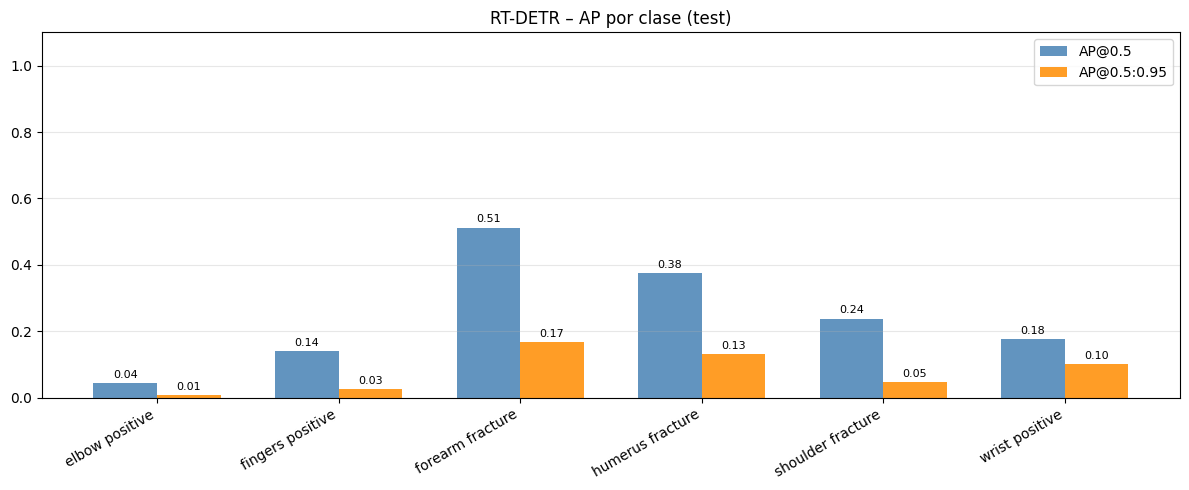

In [26]:
df_plot = df_cls.drop('** Media **', errors='ignore')

fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(df_plot)), 0.35
b1 = ax.bar(x - w/2, df_plot['AP@0.5'],       w, label='AP@0.5',      color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, df_plot['AP@0.5:0.95'],  w, label='AP@0.5:0.95', color='darkorange', alpha=0.85)

for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(df_plot.index, rotation=30, ha='right')
ax.set_ylim(0, 1.1); ax.set_title('RT-DETR – AP por clase (test)'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / 'ap_per_class_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 10 – Benchmark de latencia

Medimos cuánto tarda el modelo en procesar una imagen. Usamos el mismo protocolo que en el notebook local: 10 inferencias de warmup descartadas y 100 de medición, reportando la mediana.

Mediana : 41.68 ms/img
P95     : 46.38 ms/img
FPS     : 24.0


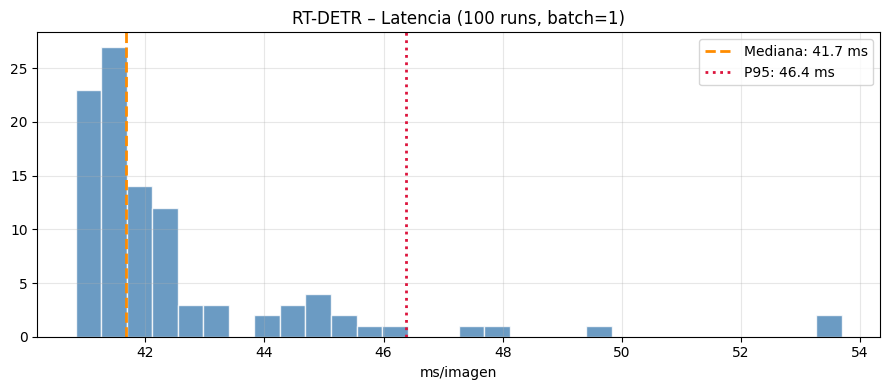

In [14]:
import time

test_imgs = list((DATA_ROOT / 'test' / 'images').glob('*.jpg'))
random.seed(SEED)
sample_img = str(random.choice(test_imgs))

# Warmup
for _ in range(10):
    model_best.predict(source=sample_img, imgsz=CFG['imgsz'],
                       conf=CFG['conf'], device=DEVICE, verbose=False)

# Medición
latencies = []
for _ in range(100):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    model_best.predict(source=sample_img, imgsz=CFG['imgsz'],
                       conf=CFG['conf'], device=DEVICE, verbose=False)
    torch.cuda.synchronize()
    latencies.append((time.perf_counter() - t0) * 1000)

lat_med = np.median(latencies)
lat_p95 = np.percentile(latencies, 95)

print(f'Mediana : {lat_med:.2f} ms/img')
print(f'P95     : {lat_p95:.2f} ms/img')
print(f'FPS     : {1000/lat_med:.1f}')

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(latencies, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(lat_med, color='darkorange', lw=2, ls='--', label=f'Mediana: {lat_med:.1f} ms')
ax.axvline(lat_p95, color='crimson',    lw=2, ls=':',  label=f'P95: {lat_p95:.1f} ms')
ax.set_xlabel('ms/imagen'); ax.set_title('RT-DETR – Latencia (100 runs, batch=1)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / 'latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 11 – Matriz de confusión

La matriz de confusión nos muestra dónde se equivoca el modelo: qué clases confunde entre sí, cuántos falsos negativos tiene (fracturas que no detectó) y cuántos falsos positivos (detecciones donde no había nada).

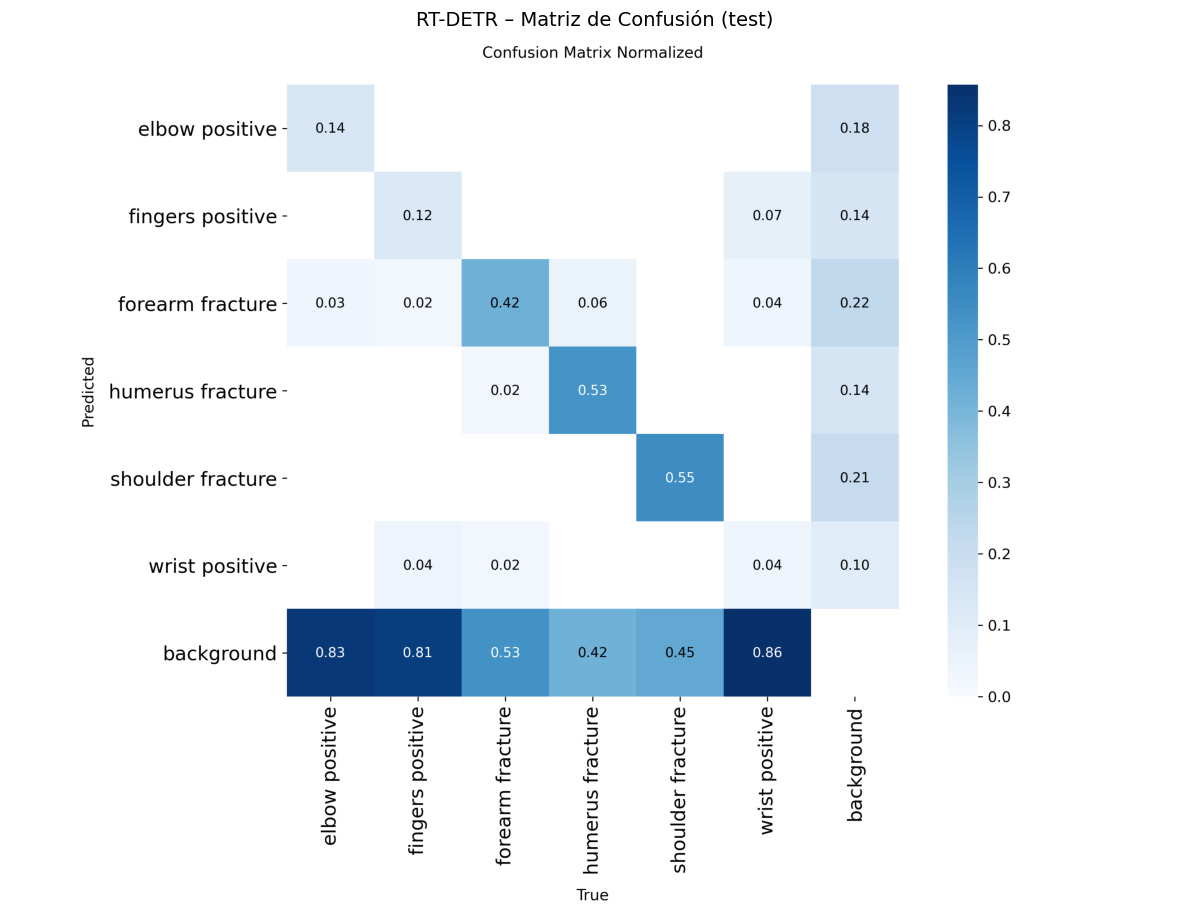

In [27]:
from PIL import Image

cm_candidates = [
    RUN_DIR / 'confusion_matrix_normalized.png',
    RUN_DIR / 'confusion_matrix.png',
]
cm_path = next((p for p in cm_candidates if p.exists()), None)

if cm_path:
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(Image.open(cm_path))
    ax.axis('off')
    ax.set_title('RT-DETR – Matriz de Confusión (test)', fontsize=14)
    plt.tight_layout(); plt.show()
else:
    print('Generando matriz de confusión manualmente...')
    from ultralytics.utils.metrics import ConfusionMatrix
    cm = ConfusionMatrix(nc=NUM_CLASSES, conf=CFG['conf'], iou_thres=CFG['iou'])

    for img_path in sorted((DATA_ROOT / 'test' / 'images').glob('*.jpg')):
        preds  = model_best.predict(source=str(img_path), imgsz=CFG['imgsz'],
                                    conf=CFG['conf'], device=DEVICE, verbose=False)
        lp     = DATA_ROOT / 'test' / 'labels' / (img_path.stem + '.txt')
        result = preds[0]
        h, w   = result.orig_shape

        det = torch.zeros((0, 6))
        if result.boxes is not None and len(result.boxes):
            det = torch.cat([result.boxes.xyxy.cpu(),
                             result.boxes.conf.cpu().unsqueeze(1),
                             result.boxes.cls.cpu().unsqueeze(1)], dim=1)

        gt = torch.zeros((0, 5))
        if lp.exists() and lp.stat().st_size > 0:
            rows_gt = []
            for line in lp.read_text().splitlines():
                if line.strip():
                    c, cx, cy, bw, bh = map(float, line.split())
                    rows_gt.append([c, (cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
            if rows_gt:
                gt = torch.tensor(rows_gt)
        cm.process_batch(det, gt)

    cm.plot(normalize=True, save_dir=str(RUN_DIR), names=CLASS_NAMES)
    plt.show()

---
## Sección 12 – Visualización de predicciones

Mostramos 9 imágenes del test con las bounding boxes reales (verde) y las predicciones del modelo (azul). Sirve para ver cualitativamente si el modelo localiza bien las fracturas.

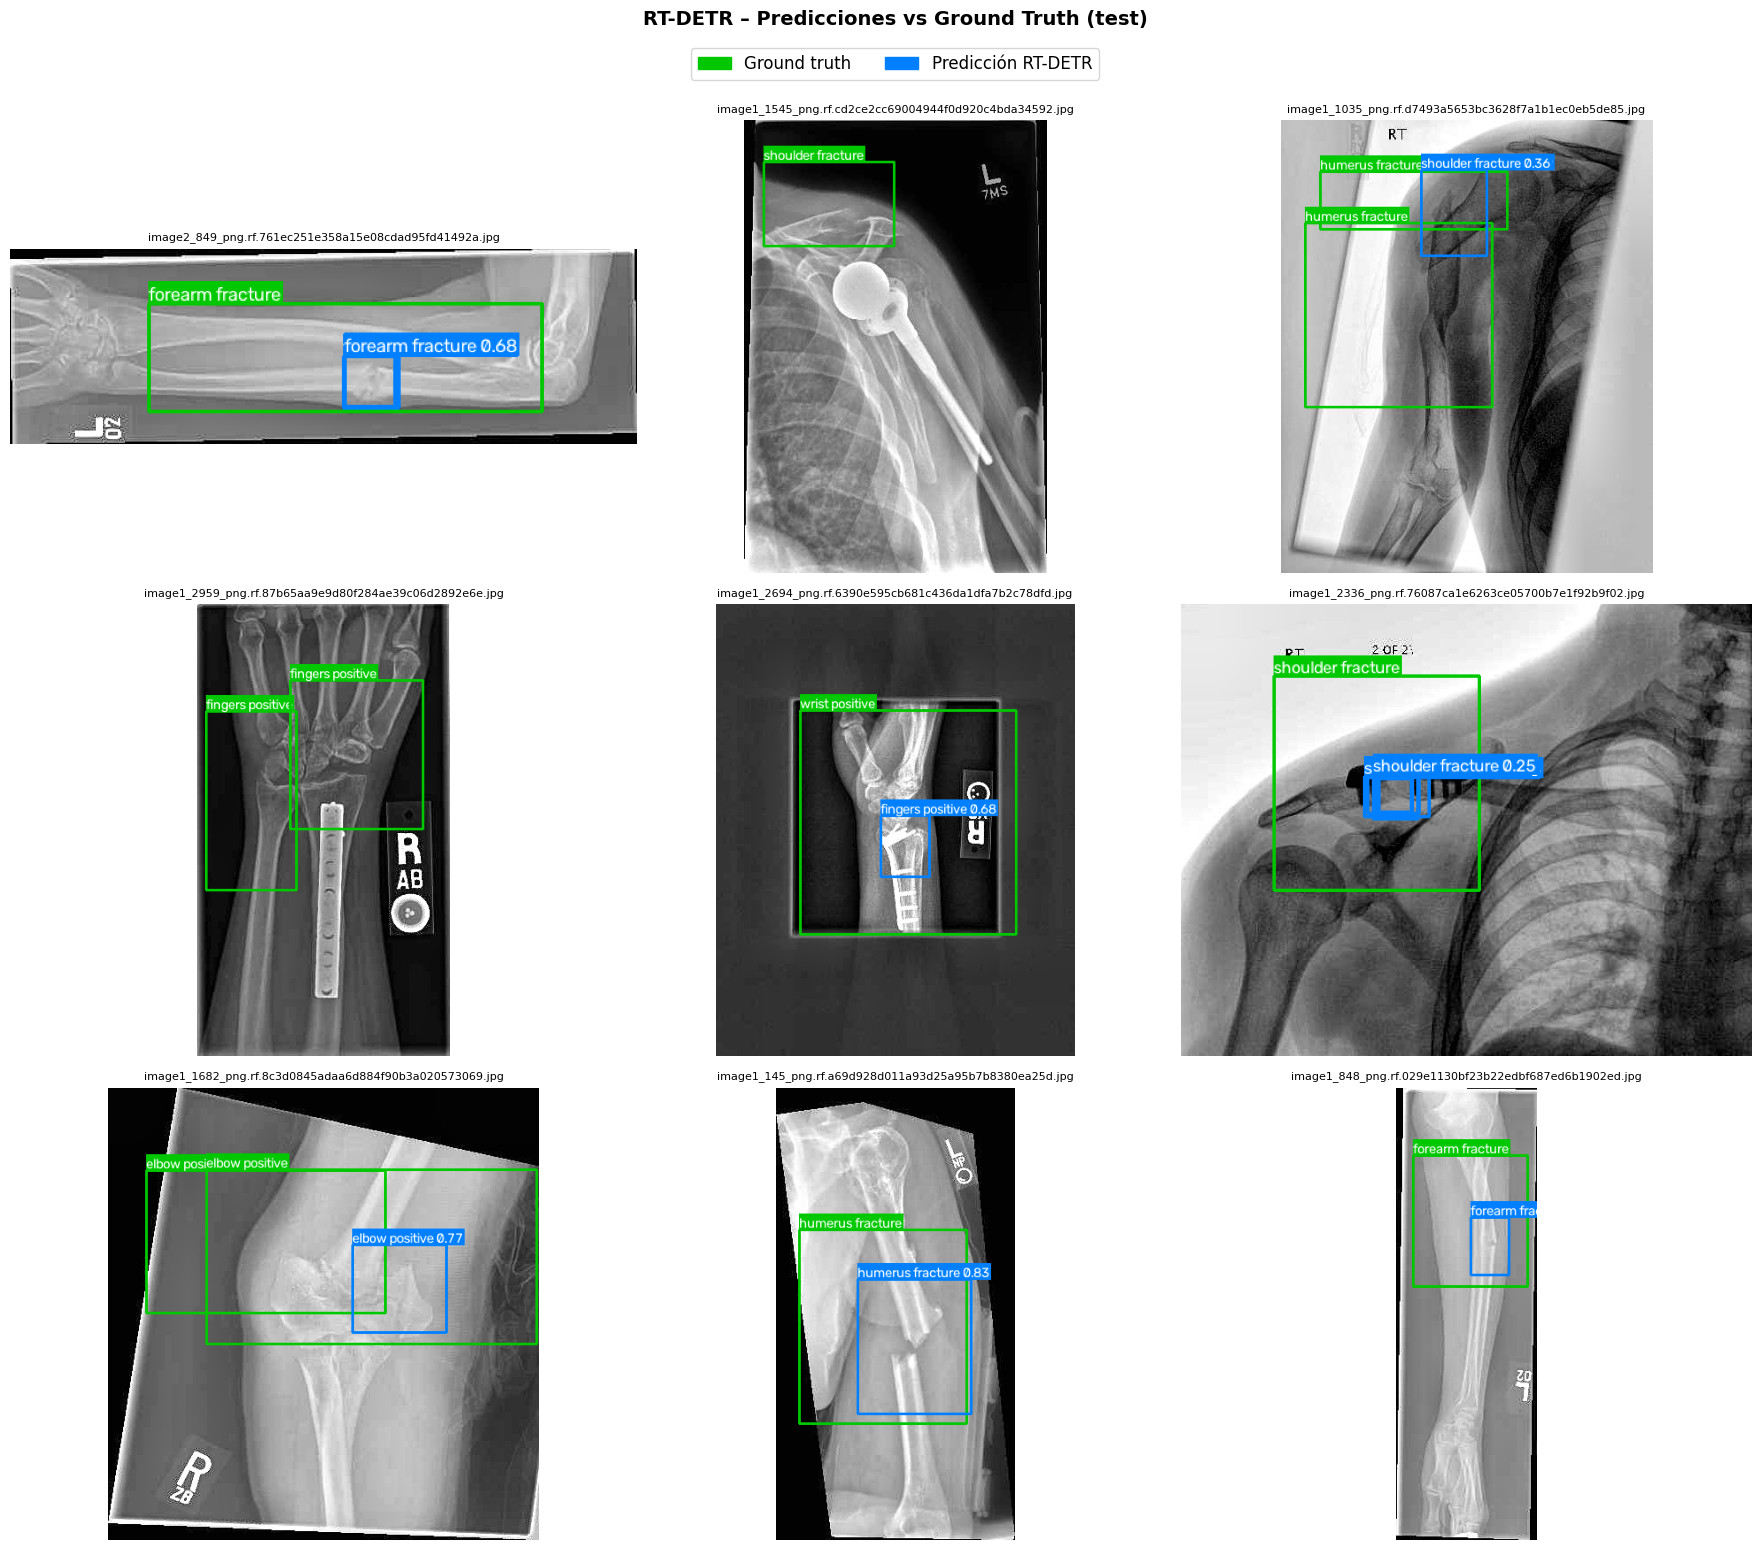

In [31]:
import cv2
import matplotlib.patches as mpatches

def draw_boxes(img, boxes, labels, color, th=2, fs=0.5):
    img = img.copy()
    for box, lbl in zip(boxes, labels):
        x1,y1,x2,y2 = [int(v) for v in box]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, th)
        (tw,th2),_ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, fs, 1)
        cv2.rectangle(img, (x1,y1-th2-4), (x1+tw,y1), color, -1)
        cv2.putText(img, lbl, (x1,y1-2), cv2.FONT_HERSHEY_SIMPLEX, fs, (255,255,255), 1)
    return img

annotated = [p for p in sorted((DATA_ROOT/'test'/'labels').glob('*.txt')) if p.stat().st_size > 0]
random.seed(SEED)
selected = random.sample(annotated, min(9, len(annotated)))

GT_C, PR_C = (0,200,0), (255,128,0)
nrows, ncols = (len(selected)+2)//3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5))
axes = axes.flatten()

for idx, lp in enumerate(selected):
    ip = DATA_ROOT / 'test' / 'images' / (lp.stem + '.jpg')
    bgr = cv2.imread(str(ip))
    h, w = bgr.shape[:2]

    gt_b, gt_l = [], []
    for line in lp.read_text().splitlines():
        if line.strip():
            # Tomar solo los primeros 5 valores (class_id, x_center, y_center, width, height)
            ci,cx,cy,bw,bh = map(float, line.split()[:5])
            gt_b.append([int((cx-bw/2)*w), int((cy-bh/2)*h), int((cx+bw/2)*w), int((cy+bh/2)*h)])
            gt_l.append(CLASS_NAMES[int(ci)])

    res = model_best.predict(source=str(ip), imgsz=CFG['imgsz'],
                             conf=CFG['conf'], device=DEVICE, verbose=False)[0]
    pr_b, pr_l = [], []
    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].cpu()]
            pr_b.append([x1,y1,x2,y2])
            pr_l.append(f'{CLASS_NAMES[int(box.cls[0].cpu())]} {float(box.conf[0].cpu()):.2f}')

    vis = draw_boxes(draw_boxes(bgr, gt_b, gt_l, GT_C), pr_b, pr_l, PR_C)
    axes[idx].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(ip.name, fontsize=8); axes[idx].axis('off')

for i in range(len(selected), len(axes)): axes[i].axis('off')

fig.legend(handles=[
    mpatches.Patch(color=(0,.78,0),      label='Ground truth'),
    mpatches.Patch(color=(0,.50,1),      label='Predicción RT-DETR'),
], loc='upper center', ncol=2, bbox_to_anchor=(0.5,1.01), fontsize=12)

fig.suptitle('RT-DETR – Predicciones vs Ground Truth (test)', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RUN_DIR / 'qualitative_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Sección 13 – Guardar resultados en Drive

Copiamos todo de `/content/rtdetr_results/` a Drive para no perder nada cuando se cierre la sesión. Esto incluye los checkpoints, las curvas, las métricas por clase y las visualizaciones.

In [29]:
import shutil

# Copiar el run completo a Drive
dest = Path(RESULTS_DRIVE) / RUN_NAME
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree(str(RUN_DIR), str(dest))
print(f'Resultados guardados en Drive: {dest}')

# Verificar archivos guardados
saved = list(dest.rglob('*'))
print(f'Archivos copiados: {len(saved)}')
for f in sorted(saved):
    if f.is_file():
        size = f.stat().st_size / 1e6
        print(f'  {f.relative_to(dest)} ({size:.1f} MB)')

Resultados guardados en Drive: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/rtdetr_fracture
Archivos copiados: 27
  BoxF1_curve.png (0.2 MB)
  BoxPR_curve.png (0.2 MB)
  BoxP_curve.png (0.3 MB)
  BoxR_curve.png (0.2 MB)
  ap_per_class_test.png (0.1 MB)
  args.yaml (0.0 MB)
  confusion_matrix.png (0.2 MB)
  confusion_matrix_normalized.png (0.3 MB)
  labels.jpg (0.2 MB)
  latency_distribution.png (0.0 MB)
  metrics_per_class_test.csv (0.0 MB)
  qualitative_predictions.png (1.3 MB)
  results.csv (0.0 MB)
  results.png (0.3 MB)
  train_batch0.jpg (0.3 MB)
  train_batch1.jpg (0.3 MB)
  train_batch2.jpg (0.3 MB)
  training_curves.png (0.2 MB)
  val_batch0_labels.jpg (0.4 MB)
  val_batch0_pred.jpg (0.4 MB)
  val_batch1_labels.jpg (0.4 MB)
  val_batch1_pred.jpg (0.4 MB)
  val_batch2_labels.jpg (0.4 MB)
  val_batch2_pred.jpg (0.4 MB)
  weights/best.pt (66.2 MB)
  weights/last.pt (66.2 MB)


In [30]:
# Tabla de resultados finales para el paper
summary = {
    'Modelo'       : 'RT-DETR-L',
    'mAP@0.5'      : round(float(test_results.box.map50), 4),
    'mAP@0.5:0.95' : round(float(test_results.box.map),   4),
    'Precision'    : round(float(P),      4),
    'Recall'       : round(float(R),      4),
    'F1'           : round(float(F1),     4),
    'Latencia (ms)': round(lat_med,       2),
    'FPS (est.)'   : round(1000/lat_med,  1),
    'GPU'          : torch.cuda.get_device_name(0),
}

df_summary = pd.DataFrame([summary]).set_index('Modelo')
print('\nResumen final – RT-DETR (TEST):')
print(df_summary.T.to_string())

df_summary.to_csv(dest / 'final_results.csv')
print(f'\nGuardado en Drive: {dest}/final_results.csv')


Resumen final – RT-DETR (TEST):
Modelo                     RT-DETR-L
mAP@0.5                       0.2475
mAP@0.5:0.95                  0.0802
Precision                     0.3204
Recall                        0.2573
F1                            0.2854
Latencia (ms)                  41.68
FPS (est.)                      24.0
GPU            NVIDIA A100-SXM4-80GB

Guardado en Drive: /content/drive/MyDrive/VPCII_TP/resultados_rtdetr/rtdetr_fracture/final_results.csv


---
## Notas del experimento

| Campo | Valor |
|---|---|
| Modelo | `rtdetr-l.pt` |
| Dataset | bone-fracture-detection-daoon-1-preprocessed (P2) |
| GPU Colab | NVIDIA A100-SXM4-80GB |
| Tiempo de entrenamiento | 2.16 horas |
| Épocas entrenadas | 58 / 100 (early stopping, `patience=20`; mejor resultado en época 38) |
| mAP@0.5 (test) | 0.2475 |
| mAP@0.5:0.95 (test) | 0.0802 |
| F1 (test) | 0.2854 |
| Latencia mediana | 41.68 ms (24.0 FPS) |

### Observaciones
- **Convergencia:** rápida durante las primeras ~30-38 épocas, después entra en meseta. El `EarlyStopping` cortó correctamente en la época 58 sin pérdida de calidad, ya que `best.pt` corresponde a la época 38.
- **Clase con mejor AP:** `forearm fracture` (AP@0.5 = 0.512, F1 = 0.626) — la clase con más instancias de train junto con `fingers positive`.
- **Clase con peor AP:** `elbow positive` (AP@0.5 = 0.043, Precision = Recall = 0 al umbral de confianza de inferencia 0.25) — el modelo prácticamente no aprendió a detectar esta clase, la de menor soporte en test (17 instancias).
- **Desbalance de clases:** el mAP global (0.2475) está dominado a la baja por `elbow positive` y `wrist positive` (6 instancias en test); las clases con más soporte (`forearm`, `humerus`) alcanzan F1 > 0.4.
- **Fixes aplicados durante el experimento:** `amp=False` (evita NaN en atención de RT-DETR), `optimizer=AdamW` explícito (por defecto Ultralytics usa `optimizer=auto` e ignora `lr0`), y remoción de `conf=0.25` en las llamadas a `.val()` (pasar `conf` ahí trunca la curva P-R y subestima el mAP real).
- **Diferencias vs YOLOv11:** pendiente — falta correr la evaluación de test de YOLOv11 para comparar.